 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submission 
Name           : Craig Lawson                <br>
Student Number : L00196711         <br>
Due Date       : May 12, 2026, 22:59 UTC                <br>
Assignment     : CA2             <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [1]:
# pip installs
%pip install opencv-python pytesseract pillow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


## Imports

In [2]:
# imports
# Had to run sudo apt-get install -y libgl1 dependency for opencv
import os
import cv2
import pytesseract
import numpy as np
import matplotlib.pyplot as plt
import re

from pathlib import Path
from PIL import Image

# Support Functions

In [3]:
# code here
#NLP Preprocess
def preprocess_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )
    
    return thresh

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9.\n ]', '', text)
    return text

def extract_total(text):
    lines = text.split('\n')
    
    for line in lines:
        if "total" in line:
            nums = re.findall(r'\d+\.\d{2}', line)
            if nums:
                return nums[-1]
    
    return None

def extract_date(text):
    match = re.search(r'\d{2}[/-]\d{2}[/-]\d{2,4}', text)
    return match.group() if match else None

def extract_merchant(text):
    for line in text.split('\n'):
        if len(line.strip()) > 4:
            return line.strip()
    return None

# NLP

## Sub Heading 1

In [16]:
## code

# Vision

## Sub Heading 1

In [4]:
# code here...
print("cv2", cv2.__version__)
print("pytesseract", pytesseract.__version__)
img = cv2.imread('data/receipts/1.jpg')
print(img.shape)

cv2 4.13.0
pytesseract 0.3.13
(1024, 688, 3)


In [5]:
# Adding custom options for tesseract
# using the latest tesseract verion 5.0, these values are better work well
custom_config = r'--oem 1 --psm 6'  

#Convert image to String
st = pytesseract.image_to_string(img, config=custom_config)
# print output
print(st)

= og
( TRADER JOE’S
2001 Greenville Ave
Dallas TX 75206
Store #403 - (469) 334-0614
OPEN 8:00AM TO 9:00PM DAILY
R-CARROTS SHREDDED 10 OZ 1,29
R-CUCUMBERS PERSIAN 1 LB ee)
TOMATOES CRUSHED NO SALT 1.59
TOMATOES WHOLE NO SALT W/BASIL 1.59
ORGANIC OLD FASHIONED OATMEAL 2.69
MINI-PEARL TOMATOES... 2.49
PKG SHREDDED MOZZARELLA CITE T — 9.99
EGGS 1 002 ORGANIC BROWN. Bale
BEANS GARBANZO 0.89
SPROUTED CA STYLE Pee)
A-AVOCADOS HASS BAG ACT 3.99
A-APPLE BAG JAZZ 2 LB el
A-PEPPER BELL EACH XL RED 0.99
GROCERY NON TAXABLE 0.98
2 @ 0.49
BANANAS ORGANIC 0.87
3FA —«@.0.29/EA
CREAMY SALTED PEANUT BUT TER 2.49
WHL WHT PITA BREAD 1.69
GROCERY NON TAXABLE 1,38
2 @ 0.69
SUBTOTAL $38 .68
TOTAL $38 .68
CASH $40.00
CHANGE $1.32
ITEMS 22 Higgins, Ryan
06-28-2014 12:34PM 0403 04 1346 4683
THANK YOU FOR SHOPPING AT
TRADER JOE'S
www. traderjoes .com



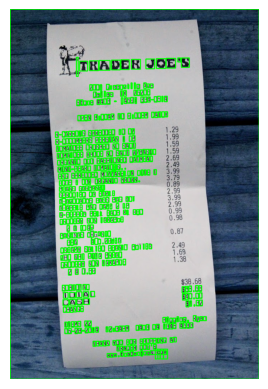

In [19]:
h, w, c = img.shape
boxes = pytesseract.image_to_boxes(img)
for b in boxes.splitlines():
    b = b.split(' ')
    img = cv2.rectangle(img, (int(b[1]), h - int(b[2])), (int(b[3]), h - int(b[4])), (0, 255, 0), 2) #OpenCV is in Blue, Green, Red format.

plt.imshow(img)
plt.axis("off")
plt.show()


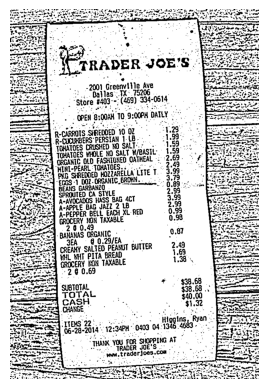

Src ies Ed a a ae
earn ee — nea
meas Bara OO ee He, rahe Bea Res
ors ie TRADER JOE’S Saree
ee -2001 Greenville Ave Beye
Perse 2. Dallas TX 15208 CoE W AD OERS
hanes 2 Store #403°~, (469) 334-0614 wenn
oot RL ee
—————F RCHMROTS SHREDOED 10 02 Se Ee
ioe R-GUMBERS PERSTAN T:UB@ 2 1BO me ET
eet | TOMATOES CRUSHED NO SALT. <0. 133 0:2 ° Serer
Eset TOMATOES MOLE HO SALT wea 159". MESS iteats
ESSEC ORGANIC OLD FASHIONED OATHERL 269. ¢ Paes
Sappicc Y MINI- PEARL TORATOES ar 5g A Res ee Be
rE SeSA pag SHREDDED MOLTARELLA LITE T 3:98 ea
1 Se 74 “E566 1 DOL. ORGANIC. BROHN 379 BESS
Bee re | BEANS GRRBANG | 0.89 2c eae pop aeeate
sanicgee | SPROUTED CA STWLE 298 Da ores
Mr ated AAvOCADOS PASS. BAG 4CT 3.98 ees
Gai chyn ArAPPLE BAG IRIE Z UB 2.98 ETI ree
ores ee A-PEPGER BELL EACH XL-RED 0.99 Gee eee
asp GROCERY NOW TAXABLE 0.93 ee FREE ET
eee 240.49 ; a CED
SEE Te] ARANAS ORGANS 0.87 os
Secs Ak ke eres
SSrddiesv04 OREANY SALTED PEANUT BUTTER 2.49 err
Sesegery MHL AMT PITA BNEAD 1.68 poy
ores 4 GRO

In [6]:
processed = preprocess_image(img)

plt.imshow(processed, cmap="gray")
plt.axis("off")
plt.show()

st = pytesseract.image_to_string(processed, config=custom_config)
print(st)

In [21]:
cleaned = clean_text(st)
print(cleaned)

ae nsti rent ners tae es ew ee
aaa bet ea er  eas
tg ee ge en ioe
silos ae y ses re ie area tt
pats wimniadee soes pei
oe  grecia b23 eaters
eesores oo dalla 1s toma sears
oa soe qa wees
acmaee bae teen dooce 1 us str  bees
ss ba beg tee eee ree aes 
robe eps
bd vncce pce eco os a en santos fats
fsectens  oomsnss dgs 8 bead 1159..  epee
roxane siaseg rats so esn a7bnsto 1.59 ee rsa
aoe wr pea essed owes  2.69. peo ates
sass mencorerrd muprtoes ee bob use eat reapaics
ee sean xy sagan sills ats pra d 3.93 se
eaten ee era rent pel er a een
spey 20189 can po
store gamer moa el deceaeerse
gee cy ae 630 eal 32 periieeesiee
oes au og 2.88 eabrreoes
eae ces gbeepen geek bh 2 bod 0.93 er aaron
styecce cgmdee bin testa 088 raesaesd
assert ar bao  seer
as ossethes sn 0.87 inet anes
seas pee cago  sy eas.
i gamnesem tg be
eet  bom ay
sme guerd soy tscs0g ih en see
facies 8 80 lee
si  eran
apcsoee grid  908. ree
e wowad aa aan
seecrnee ee as  . a eee
se ol oa pepper
emcee ies 28 s. atgates bran es

In [25]:
data = {
    "merchant": extract_merchant(cleaned),
    "date": extract_date(cleaned),
    "total": extract_total(cleaned)
}

print(data)

{'merchant': 'ae nsti rent ners tae es ew ee', 'date': None, 'total': None}


# Multi-modal

## Sub Heading 1

In [22]:
# code here

# Final Output

In [23]:
# code